<a href="https://colab.research.google.com/github/paperback99-byte/BAYESIAN-QUANTUM-GAMES/blob/main/BAYESIAN_QUANTUM_GAMES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

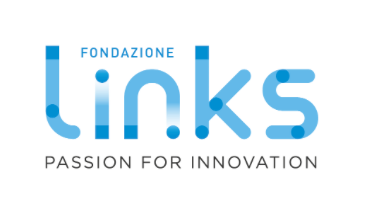

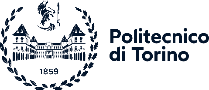

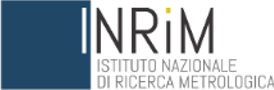

# LAGRANGE IQM Spark quantum superconductive computer - Exam Hello world
##### 3 March 2026

*   version for exams only, without comments, it is supposed users know well what to do

## Verify bookings in the [Lagrange portal]
https://dashboard.quantum.linksfoundation.com/

## Here there is the [IQM Documentation]
https://status.quantum.linksfoundation.com/

https://docs.meetiqm.com/iqm-client/readme.html  

https://gitlab.linksfoundation.com/links-iqm-spark/examples/-/blob/main/Grover_qiskit_lagrange.ipynb?ref_type=heads )

## Check machine status in the [Lagrange dashboard]
https://status.quantum.linksfoundation.com/

https://grafana.quantum.linksfoundation.com/d/de153ad5-136e-40c7-8917-99bfe8a3197e/calibration-set-metrics?orgId=1&from=now-2d&to=now&timezone=Europe%2FRome

In [1]:
%pip install uv --quiet
!uv pip install "iqm-client[qiskit]==33.0.4" --quiet
!uv pip install matplotlib --quiet
!uv pip install lagrangeclient --index-url https://gitlab.linksfoundation.com/api/v4/projects/1709/packages/pypi/simple

%pip install qrisp==0.8

%pip install matplotlib pylatexenc --quiet # only for visualization purposes

!lagrangeclient

from iqm import qiskit_iqm

Using Python 3.13.15 environment at: /usr
Checked 1 package in 113ms
== DEVICE LOGIN FLOW ==
🔗 Visit this URL in your browser:
https://spark.quantum.linksfoundation.com/auth/realms/cortex/device?user_code=XTQE-SGZR
Waiting for user to complete login...
=========== TOKEN ===========
eyJhbGciOiJSUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICJPN2g5cUtOOGRsdi1OZlo3Qm10NEJNZC0yaUFnMWt5STFEa2h0R3M5OU5rIn0.eyJleHAiOjE3ODk5MjI0NDEsImlhdCI6MTc4OTMxNzY0MSwiYXV0aF90aW1lIjoxNzg5MzE3MDcwLCJqdGkiOiJvbnJ0ZGc6N2M5MWNiZTgtYzBkMi1hYzhkLWI3Y2UtZTA4YTVjODA3MGU0IiwiaXNzIjoiaHR0cHM6Ly9zcGFyay5xdWFudHVtLmxpbmtzZm91bmRhdGlvbi5jb20vYXV0aC9yZWFsbXMvY29ydGV4IiwiYXVkIjoiYWNjb3VudCIsInN1YiI6IjFkNzc4ZThhLWVmMTAtNGVjYS1iZTQwLTk2N2UwMzYwYTY2ZCIsInR5cCI6IkJlYXJlciIsImF6cCI6ImlxbV9jbGllbnQiLCJzaWQiOiJlY2YxNjVhNS1mNDVkLTQ1OTgtOGViMy1mMWUzZWI0NzI0MGIiLCJhY3IiOiIwIiwiYWxsb3dlZC1vcmlnaW5zIjpbImh0dHBzOi8vc3BhcmsucXVhbnR1bS5saW5rc2ZvdW5kYXRpb24uY29tLyoiLCJodHRwczovL2Rhc2hib2FyZC5xdWFudHVtLmxpbmtzZm91bmRhdGlvbi5jb20iXSwicmVhbG1fYWNjZ

     ┌───┐┌─┐
q_0: ┤ H ├┤M├
     └┬─┬┘└╥┘
q_1: ─┤M├──╫─
      └╥┘  ║ 
c: 2/══╩═══╩═
       1   0 
01a09ba4-ad54-7681-bfaf-691b17ea6c58
{'00': 513, '01': 497, '11': 7, '10': 7}


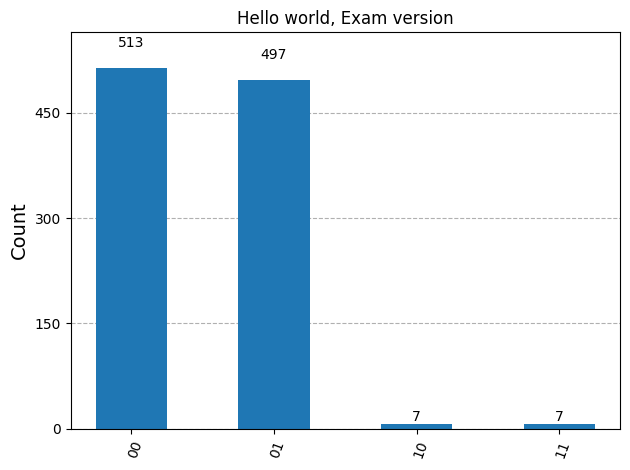

In [2]:
from qiskit import QuantumCircuit

from qiskit import QuantumCircuit
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.measure([0,1],[0,1])

# circuit.draw(output='mpl', scale=0.8)

print(circuit.draw(output='text'))

from iqm.qiskit_iqm import IQMProvider
from qiskit import transpile
from qiskit.visualization import plot_histogram
import os

os.environ["IQM_TOKENS_FILE"] = "./tokens.json"
iqm_url = "https://spark.quantum.linksfoundation.com/"
quantum_computer = "default"

provider = IQMProvider(iqm_url, quantum_computer=quantum_computer)
backend = provider.get_backend()


transpiled_circuit = transpile(circuit, backend=backend)
# transpiled_circuit.metadata["project"] = "project_name_as_provided"   // if not specified it is the default one
job = backend.run([transpiled_circuit], shots=1024)
counts = job.result().get_counts()
print(job.job_id())
print(counts)
from qiskit.visualization import plot_histogram
plot_histogram(counts, title="Hello world, Exam version")


In [3]:
import numpy as np
from itertools import product

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

STRATEGIES DEFINITION

In [4]:
STRATEGIES = ["I", "X", "Y", "Z"]


def apply_J(qc, theta, qA, qB):
    """
    J(theta) = exp(+i theta X⊗X)

    Qiskit:
    RXX(phi) = exp(-i phi/2 X⊗X)

    therefore:
    J(theta) = RXX(-2 theta)
    """
    qc.rxx(-2 * theta, qA, qB)


def apply_J_dagger(qc, theta, qA, qB):
    """
    J†(theta) = exp(-i theta X⊗X)
              = RXX(+2 theta)
    """
    qc.rxx(+2 * theta, qA, qB)

In [5]:
def apply_strategy(qc, strategy, qubit):

    if strategy == "I":
        pass

    elif strategy == "X":
        qc.x(qubit)

    elif strategy == "Y":
        qc.y(qubit)

    elif strategy == "Z":
        qc.z(qubit)

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

CREATION OF 16 CIRCUITS TO COVER ALL THE STRATEGY SETS USING ONLY 2 QUBITS


In [6]:
def create_2q_circuit(theta, UA, UB):

    qc = QuantumCircuit(2)

    # Entanglement
    apply_J(qc, theta, 0, 1)

    # Strategies
    apply_strategy(qc, UA, 0)
    apply_strategy(qc, UB, 1)

    # Disentanglement
    apply_J_dagger(qc, theta, 0, 1)

    return qc

In [7]:
def create_all_2q_circuits(theta):

    circuits = {}

    for UA, UB in product(STRATEGIES, repeat=2):

        circuits[(UA, UB)] = create_2q_circuit(
            theta,
            UA,
            UB
        )

    return circuits

In [8]:
theta = np.pi / 20

circuits_2q = create_all_2q_circuits(theta)

In [9]:
for strategy_pair, circuit in circuits_2q.items():

    print("\n", strategy_pair)
    print(circuit.draw("text"))


 ('I', 'I')
     ┌─────────────┐┌────────────┐
q_0: ┤0            ├┤0           ├
     │  Rxx(-π/10) ││  Rxx(π/10) │
q_1: ┤1            ├┤1           ├
     └─────────────┘└────────────┘

 ('I', 'X')
     ┌─────────────┐     ┌────────────┐
q_0: ┤0            ├─────┤0           ├
     │  Rxx(-π/10) │┌───┐│  Rxx(π/10) │
q_1: ┤1            ├┤ X ├┤1           ├
     └─────────────┘└───┘└────────────┘

 ('I', 'Y')
     ┌─────────────┐     ┌────────────┐
q_0: ┤0            ├─────┤0           ├
     │  Rxx(-π/10) │┌───┐│  Rxx(π/10) │
q_1: ┤1            ├┤ Y ├┤1           ├
     └─────────────┘└───┘└────────────┘

 ('I', 'Z')
     ┌─────────────┐     ┌────────────┐
q_0: ┤0            ├─────┤0           ├
     │  Rxx(-π/10) │┌───┐│  Rxx(π/10) │
q_1: ┤1            ├┤ Z ├┤1           ├
     └─────────────┘└───┘└────────────┘

 ('X', 'I')
     ┌─────────────┐┌───┐┌────────────┐
q_0: ┤0            ├┤ X ├┤0           ├
     │  Rxx(-π/10) │└───┘│  Rxx(π/10) │
q_1: ┤1            ├─────┤1           ├


CREATION OF 2 CIRCUITS COVERING ALL 16 STRATEGY SETS USING 5 QUBITS (3 ANCILLAS
)

In [10]:
def create_5q_IZ_circuit(theta):

    qc = QuantumCircuit(5)

    # --------------------------------
    # Auxiliary qubits -> |+++>
    # --------------------------------

    qc.h(2)
    qc.h(3)
    qc.h(4)

    # --------------------------------
    # J(theta) between A and B
    # --------------------------------

    apply_J(qc, theta, 0, 1)

    # --------------------------------
    # Strategies of A
    # --------------------------------

    # x controls X_A
    qc.cx(2, 0)

    # y controls Z_A
    qc.cz(3, 0)

    # --------------------------------
    # Strategies of B
    # --------------------------------

    # z controls Z_B
    qc.cz(4, 1)

    # --------------------------------
    # J†(theta)
    # --------------------------------

    apply_J_dagger(qc, theta, 0, 1)

    return qc

In [11]:
def create_5q_XY_circuit(theta):

    qc = QuantumCircuit(5)

    # Auxiliary qubits -> |+++>
    qc.h(2)
    qc.h(3)
    qc.h(4)

    # J(theta)
    apply_J(qc, theta, 0, 1)

    # Strategies of A
    qc.cx(2, 0)
    qc.cz(3, 0)

    # Controlled Z contribution on B
    qc.cz(4, 1)

    # Additional X on B
    qc.x(1)

    # J†(theta)
    apply_J_dagger(qc, theta, 0, 1)

    return qc

In [12]:
circuit_5q_IZ = create_5q_IZ_circuit(theta)
circuit_5q_XY = create_5q_XY_circuit(theta)

In [13]:
print(circuit_5q_IZ.draw("text"))

     ┌─────────────┐┌───┐      ┌────────────┐
q_0: ┤0            ├┤ X ├────■─┤0           ├
     │  Rxx(-π/10) │└─┬─┘    │ │  Rxx(π/10) │
q_1: ┤1            ├──┼───■──┼─┤1           ├
     └────┬───┬────┘  │   │  │ └────────────┘
q_2: ─────┤ H ├───────■───┼──┼───────────────
          ├───┤           │  │               
q_3: ─────┤ H ├───────────┼──■───────────────
          ├───┤           │                  
q_4: ─────┤ H ├───────────■──────────────────
          └───┘                              


In [14]:
print(circuit_5q_XY.draw("text"))

     ┌─────────────┐┌───┐           ┌────────────┐
q_0: ┤0            ├┤ X ├────■──────┤0           ├
     │  Rxx(-π/10) │└─┬─┘    │ ┌───┐│  Rxx(π/10) │
q_1: ┤1            ├──┼───■──┼─┤ X ├┤1           ├
     └────┬───┬────┘  │   │  │ └───┘└────────────┘
q_2: ─────┤ H ├───────■───┼──┼────────────────────
          ├───┤           │  │                    
q_3: ─────┤ H ├───────────┼──■────────────────────
          ├───┤           │                       
q_4: ─────┤ H ├───────────■───────────────────────
          └───┘                                   


STRATEGY MAPPING (according to the paper)

In [15]:
AUX_TO_A_STRATEGY = {
    (0, 0): "I",
    (1, 0): "X",
    (0, 1): "Z",
    (1, 1): "Y"
}

In [16]:
AUX_TO_B_IZ = {
    0: "I",
    1: "Z"
}

In [17]:
AUX_TO_B_XY = {
    0: "X",
    1: "Y"
}

In [18]:
def exact_probabilities_2q(circuit):

    state = Statevector.from_instruction(circuit)

    raw_probs = state.probabilities_dict()

    probabilities = {
        "00": 0.0,
        "01": 0.0,
        "10": 0.0,
        "11": 0.0
    }

    for bitstring, probability in raw_probs.items():

        # Qiskit displays q1 q0.
        # We want A B = q0 q1.
        AB = bitstring[::-1]

        probabilities[AB] = float(probability)

    return probabilities

In [19]:
def exact_probabilities_all_2q(circuits):

    results = {}

    for strategy_pair, circuit in circuits.items():

        results[strategy_pair] = exact_probabilities_2q(
            circuit
        )

    return results

In [20]:
probabilities_2q = exact_probabilities_all_2q(
    circuits_2q
)

In [21]:
def extract_5q_probabilities(circuit, block):
    """
    Extract the conditional P(A,B) associated with
    each auxiliary-qubit configuration.

    block = "IZ"  -> B strategies I,Z
    block = "XY"  -> B strategies X,Y
    """

    state = Statevector.from_instruction(circuit)

    raw_probs = state.probabilities_dict()

    results = {}
    branch_probability = {}

    # Initialize all possible strategy pairs
    for x, y, z in product([0, 1], repeat=3):

        UA = AUX_TO_A_STRATEGY[(x, y)]

        if block == "IZ":
            UB = AUX_TO_B_IZ[z]

        elif block == "XY":
            UB = AUX_TO_B_XY[z]

        else:
            raise ValueError("block must be 'IZ' or 'XY'")

        key = (UA, UB)

        results[key] = {
            "00": 0.0,
            "01": 0.0,
            "10": 0.0,
            "11": 0.0
        }

        branch_probability[key] = 0.0

    # Read the full 5-qubit probability distribution
    for bitstring, probability in raw_probs.items():

        # Qiskit ordering:
        # q4 q3 q2 q1 q0
        #
        # reverse:
        # q0 q1 q2 q3 q4
        # A  B  x  y  z

        bits = bitstring[::-1]

        A = int(bits[0])
        B = int(bits[1])
        x = int(bits[2])
        y = int(bits[3])
        z = int(bits[4])

        UA = AUX_TO_A_STRATEGY[(x, y)]

        if block == "IZ":
            UB = AUX_TO_B_IZ[z]

        else:
            UB = AUX_TO_B_XY[z]

        strategy_pair = (UA, UB)

        outcome = f"{A}{B}"

        results[strategy_pair][outcome] += float(probability)

        branch_probability[strategy_pair] += float(probability)

    # Conditional probabilities:
    # P(A,B | strategy)
    for strategy_pair in results:

        normalization = branch_probability[strategy_pair]

        for outcome in results[strategy_pair]:

            results[strategy_pair][outcome] /= normalization

    return results

In [22]:
probabilities_5q_IZ = extract_5q_probabilities(
    circuit_5q_IZ,
    "IZ"
)

probabilities_5q_XY = extract_5q_probabilities(
    circuit_5q_XY,
    "XY"
)

In [23]:
probabilities_5q = {}

probabilities_5q.update(probabilities_5q_IZ)
probabilities_5q.update(probabilities_5q_XY)

In [24]:
print(len(probabilities_5q))

16


TEST FOR EQUIVALENCE 2q - 5q

In [25]:
def max_probability_difference(p2, p5):

    return max(
        abs(p2[outcome] - p5[outcome])
        for outcome in ["00", "01", "10", "11"]
    )

In [26]:
print("2-QUBIT vs 5-QUBIT EQUIVALENCE")
print("=" * 50)

for strategy_pair in product(STRATEGIES, repeat=2):

    p2 = probabilities_2q[strategy_pair]
    p5 = probabilities_5q[strategy_pair]

    difference = max_probability_difference(
        p2,
        p5
    )

    print(
        f"{strategy_pair}: "
        f"max |ΔP| = {difference:.3e}"
    )

2-QUBIT vs 5-QUBIT EQUIVALENCE
('I', 'I'): max |ΔP| = 3.852e-34
('I', 'X'): max |ΔP| = 3.852e-34
('I', 'Y'): max |ΔP| = 1.110e-16
('I', 'Z'): max |ΔP| = 1.110e-16
('X', 'I'): max |ΔP| = 3.852e-34
('X', 'X'): max |ΔP| = 3.852e-34
('X', 'Y'): max |ΔP| = 1.110e-16
('X', 'Z'): max |ΔP| = 1.110e-16
('Y', 'I'): max |ΔP| = 1.110e-16
('Y', 'X'): max |ΔP| = 1.110e-16
('Y', 'Y'): max |ΔP| = 3.852e-34
('Y', 'Z'): max |ΔP| = 3.852e-34
('Z', 'I'): max |ΔP| = 1.110e-16
('Z', 'X'): max |ΔP| = 1.110e-16
('Z', 'Y'): max |ΔP| = 3.852e-34
('Z', 'Z'): max |ΔP| = 3.852e-34


In [27]:
test_thetas = [
    0,
    np.pi / 40,
    np.pi / 20,
    np.pi / 10,
    np.pi / 4
]

In [28]:
print("TEST FOR DIFFERENT THETA")
print("=" * 60)

for theta_test in test_thetas:

    # -----------------------------
    # 16 two-qubit circuits
    # -----------------------------

    circuits_2q_test = create_all_2q_circuits(
        theta_test
    )

    probs_2q_test = exact_probabilities_all_2q(
        circuits_2q_test
    )

    # -----------------------------
    # two five-qubit circuits
    # -----------------------------

    circ_IZ_test = create_5q_IZ_circuit(
        theta_test
    )

    circ_XY_test = create_5q_XY_circuit(
        theta_test
    )

    probs_5q_test = {}

    probs_5q_test.update(
        extract_5q_probabilities(
            circ_IZ_test,
            "IZ"
        )
    )

    probs_5q_test.update(
        extract_5q_probabilities(
            circ_XY_test,
            "XY"
        )
    )

    # -----------------------------
    # Maximum error over all
    # 16 strategies
    # -----------------------------

    maximum_error = 0.0
    worst_strategy = None

    for strategy_pair in product(
        STRATEGIES,
        repeat=2
    ):

        error = max_probability_difference(
            probs_2q_test[strategy_pair],
            probs_5q_test[strategy_pair]
        )

        if error > maximum_error:

            maximum_error = error
            worst_strategy = strategy_pair

    print(
        f"theta = {theta_test / np.pi:.3f}π   "
        f"max |ΔP| = {maximum_error:.3e}   "
        f"worst = {worst_strategy}"
    )

TEST FOR DIFFERENT THETA
theta = 0.000π   max |ΔP| = 0.000e+00   worst = None
theta = 0.025π   max |ΔP| = 6.939e-18   worst = ('I', 'Y')
theta = 0.050π   max |ΔP| = 1.110e-16   worst = ('I', 'Y')
theta = 0.100π   max |ΔP| = 2.220e-16   worst = ('I', 'I')
theta = 0.250π   max |ΔP| = 2.465e-32   worst = ('I', 'Y')


PAYOFF CALCULATION

In [29]:
PAYOFF_B1 = {
    "00": (11, 9),
    "01": (1, 10),
    "10": (10, 1),
    "11": (6, 6)
}

PAYOFF_B2 = {
    "00": (11, 9),
    "01": (1, 6),
    "10": (10, 1),
    "11": (6, 0)
}

In [30]:
def calculate_payoff(probabilities, payoff_matrix):
    """
    Calculate the expected payoff of players A and B.

    probabilities:
        dictionary containing P(00), P(01), P(10), P(11)

    payoff_matrix:
        PAYOFF_B1 or PAYOFF_B2

    returns:
        (expected payoff of A, expected payoff of B)
    """

    payoff_A = 0.0
    payoff_B = 0.0

    for outcome, probability in probabilities.items():

        payoff_A += probability * payoff_matrix[outcome][0]
        payoff_B += probability * payoff_matrix[outcome][1]

    return payoff_A, payoff_B

In [31]:
payoffs_B1 = {}
payoffs_B2 = {}

for strategy_pair, probabilities in probabilities_2q.items():

    payoffs_B1[strategy_pair] = calculate_payoff(
        probabilities,
        PAYOFF_B1
    )

    payoffs_B2[strategy_pair] = calculate_payoff(
        probabilities,
        PAYOFF_B2
    )

In [32]:
print("PAYOFFS — A vs B1")
print("=" * 50)

for strategy_pair in product(STRATEGIES, repeat=2):

    payoff_A, payoff_B = payoffs_B1[strategy_pair]

    print(
        f"{strategy_pair}: "
        f"A = {payoff_A:.6f}, "
        f"B1 = {payoff_B:.6f}"
    )


print("\nPAYOFFS — A vs B2")
print("=" * 50)

for strategy_pair in product(STRATEGIES, repeat=2):

    payoff_A, payoff_B = payoffs_B2[strategy_pair]

    print(
        f"{strategy_pair}: "
        f"A = {payoff_A:.6f}, "
        f"B2 = {payoff_B:.6f}"
    )

PAYOFFS — A vs B1
('I', 'I'): A = 11.000000, B1 = 9.000000
('I', 'X'): A = 1.000000, B1 = 10.000000
('I', 'Y'): A = 1.859424, B1 = 9.140576
('I', 'Z'): A = 10.522542, B1 = 8.713525
('X', 'I'): A = 10.000000, B1 = 1.000000
('X', 'X'): A = 6.000000, B1 = 6.000000
('X', 'Y'): A = 6.477458, B1 = 6.286475
('X', 'Z'): A = 9.140576, B1 = 1.859424
('Y', 'I'): A = 9.140576, B1 = 1.859424
('Y', 'X'): A = 6.477458, B1 = 6.286475
('Y', 'Y'): A = 6.000000, B1 = 6.000000
('Y', 'Z'): A = 10.000000, B1 = 1.000000
('Z', 'I'): A = 10.522542, B1 = 8.713525
('Z', 'X'): A = 1.859424, B1 = 9.140576
('Z', 'Y'): A = 1.000000, B1 = 10.000000
('Z', 'Z'): A = 11.000000, B1 = 9.000000

PAYOFFS — A vs B2
('I', 'I'): A = 11.000000, B2 = 9.000000
('I', 'X'): A = 1.000000, B2 = 6.000000
('I', 'Y'): A = 1.859424, B2 = 5.522542
('I', 'Z'): A = 10.522542, B2 = 8.140576
('X', 'I'): A = 10.000000, B2 = 1.000000
('X', 'X'): A = 6.000000, B2 = 0.000000
('X', 'Y'): A = 6.477458, B2 = 0.859424
('X', 'Z'): A = 9.140576, B2 = 1

OBSERVATIONS:

1) half of strategy pairs are classical, the other half are quantum. This is NOT the classical payoff matrix: they are the expected payoff associated with the quantum strategies.

2) there are either strategies which commute with XxX and strategies that anti-commute.
For the strategies that communte, entanglement is "deleted" so we get classical strategies. For the others, basically, we don't get deterministically a cell of the payoff matrix, but a quantum superposition between two cells, and the relative payoff is the weighted average.

3) For the same pair of strategies, A's payoff don't change in the two games (e.g. against B1 and against B2). However, since B1 and B2 have different payoff function, they will have different best response(!). Consequently, "B type" will indirectly change A's payoff by changing the strategy played by B.

In [33]:
import pandas as pd

# Empty matrices
matrix_A = pd.DataFrame(
    index=STRATEGIES,
    columns=STRATEGIES,
    dtype=float
)

matrix_B1 = pd.DataFrame(
    index=STRATEGIES,
    columns=STRATEGIES,
    dtype=float
)

matrix_B2 = pd.DataFrame(
    index=STRATEGIES,
    columns=STRATEGIES,
    dtype=float
)


# Fill matrices
for UA, UB in product(STRATEGIES, repeat=2):

    payoff_A, payoff_B1 = payoffs_B1[(UA, UB)]
    _, payoff_B2 = payoffs_B2[(UA, UB)]

    matrix_A.loc[UA, UB] = payoff_A
    matrix_B1.loc[UA, UB] = payoff_B1
    matrix_B2.loc[UA, UB] = payoff_B2


print("PAYOFF MATRIX — A")
print(matrix_A.round(4))

print("\nPAYOFF MATRIX — B1")
print(matrix_B1.round(4))

print("\nPAYOFF MATRIX — B2")
print(matrix_B2.round(4))

PAYOFF MATRIX — A
         I       X       Y        Z
I  11.0000  1.0000  1.8594  10.5225
X  10.0000  6.0000  6.4775   9.1406
Y   9.1406  6.4775  6.0000  10.0000
Z  10.5225  1.8594  1.0000  11.0000

PAYOFF MATRIX — B1
        I        X        Y       Z
I  9.0000  10.0000   9.1406  8.7135
X  1.0000   6.0000   6.2865  1.8594
Y  1.8594   6.2865   6.0000  1.0000
Z  8.7135   9.1406  10.0000  9.0000

PAYOFF MATRIX — B2
        I       X       Y       Z
I  9.0000  6.0000  5.5225  8.1406
X  1.0000  0.0000  0.8594  1.4775
Y  1.4775  0.8594  0.0000  1.0000
Z  8.1406  5.5225  6.0000  9.0000


BEST RESPONSE EVALUATION, SEPARATELY

In [34]:
def best_responses_B(matrix_B):
    """
    For each strategy of A, find the best response(s) of B.
    """

    best_responses = {}

    for UA in STRATEGIES:

        row = matrix_B.loc[UA]

        max_payoff = row.max()

        best = [
            UB
            for UB in STRATEGIES
            if np.isclose(row[UB], max_payoff)
        ]

        best_responses[UA] = best

    return best_responses


BR_B1 = best_responses_B(matrix_B1)
BR_B2 = best_responses_B(matrix_B2)

print("Best responses of B1:")
print(BR_B1)

print("\nBest responses of B2:")
print(BR_B2)

Best responses of B1:
{'I': ['X'], 'X': ['Y'], 'Y': ['X'], 'Z': ['Y']}

Best responses of B2:
{'I': ['I'], 'X': ['Z'], 'Y': ['I'], 'Z': ['Z']}


BEST RESPONSE EVALUATION, BAYESIAN QUANTUM GAME

In [35]:
def best_response_A(UB1, UB2, p, matrix_A):
    """
    Find A's best response given:
        - strategy of B1
        - strategy of B2
        - Bayesian probability p
    """

    expected_payoffs = {}

    for UA in STRATEGIES:

        payoff = (
            p * matrix_A.loc[UA, UB1]
            +
            (1 - p) * matrix_A.loc[UA, UB2]
        )

        expected_payoffs[UA] = payoff

    max_payoff = max(expected_payoffs.values())

    best = [
        UA
        for UA, payoff in expected_payoffs.items()
        if np.isclose(payoff, max_payoff)
    ]

    return best, expected_payoffs

TEST

In [36]:
best_A, values = best_response_A(
    UB1="Y",
    UB2="Z",
    p=0.5,
    matrix_A=matrix_A
)

In [37]:
print("Expected payoffs of A:")

for strategy, payoff in values.items():
    print(f"{strategy}: {float(payoff):.6f}")

print("\nBest response of A:")
print(best_A)

Expected payoffs of A:
I: 6.190983
X: 7.809017
Y: 8.000000
Z: 6.000000

Best response of A:
['Y']


OBSERVATION:

p=0.5, theta=0.05pi

if A plays X => BR for B1 is Y, BR for B2 is Z

so a possibility for the Nash equilibrium could be (X,Y,Z).

But if B1=Y and B2=Z, we know now that BR for A is Y => A would like to change X->Y. So, unfortunately, (X,Y,Z) is NOT Nash. This is coherent with the paper: they did not find any Nash equilibrium for p=0.5 and theta=0.05pi.

But now let's formally compute it.. .

NASH EQUILIBRIA

In [38]:
def find_nash_equilibria(
    p,
    matrix_A,
    matrix_B1,
    matrix_B2
):
    """
    Find all pure-strategy Nash equilibria
    for a given Bayesian probability p.

    Returns a list of tuples:
        (UA, UB1, UB2)
    """

    # Best responses of B1 and B2 to every strategy of A
    BR_B1 = best_responses_B(matrix_B1)
    BR_B2 = best_responses_B(matrix_B2)

    equilibria = []

    # Check all 4^3 = 64 strategy triples
    for UA, UB1, UB2 in product(
        STRATEGIES,
        repeat=3
    ):

        # Is B1 best-responding to A?
        B1_is_best = UB1 in BR_B1[UA]

        # Is B2 best-responding to A?
        B2_is_best = UB2 in BR_B2[UA]

        # Best response(s) of A to B1, B2
        BR_A, _ = best_response_A(
            UB1=UB1,
            UB2=UB2,
            p=p,
            matrix_A=matrix_A
        )

        A_is_best = UA in BR_A

        # Nash iff everybody is best-responding
        if A_is_best and B1_is_best and B2_is_best:

            equilibria.append(
                (UA, UB1, UB2)
            )

    return equilibria

TEST: p=0.5 (nice)

In [39]:
p = 0.5

nash_equilibria = find_nash_equilibria(
    p=p,
    matrix_A=matrix_A,
    matrix_B1=matrix_B1,
    matrix_B2=matrix_B2
)

print(
    f"Nash equilibria for "
    f"theta = {theta / np.pi:.3f}π "
    f"and p = {p}:"
)

if nash_equilibria:

    for equilibrium in nash_equilibria:
        print(equilibrium)

else:
    print("No Nash equilibrium found.")

Nash equilibria for theta = 0.050π and p = 0.5:
No Nash equilibrium found.


In [40]:
p_values = np.linspace(0, 1, 101)

nash_vs_p = {}

for p in p_values:

    equilibria = find_nash_equilibria(
        p=p,
        matrix_A=matrix_A,
        matrix_B1=matrix_B1,
        matrix_B2=matrix_B2
    )

    nash_vs_p[round(float(p), 2)] = equilibria

In [41]:
for p, equilibria in nash_vs_p.items():

    if equilibria:

        print(
            f"p = {p:.2f} -> "
            f"{equilibria}"
        )

    else:

        print(
            f"p = {p:.2f} -> "
            f"No Nash equilibrium"
        )

p = 0.00 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.01 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.02 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.03 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.04 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.05 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.06 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.07 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.08 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.09 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.10 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.11 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.12 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.13 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.14 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.15 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.16 -> [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.17 -> No Nash equilibrium
p = 0.18 -> No Nash equilibrium
p = 0.19 -> No Nash equilibrium
p = 0.20 -> No Nash equilibrium
p = 0.21 -> No Nash equilibrium
p = 0.22 -> No Nash equilibrium
p = 0.23 

In [42]:
def compact_nash_regions(nash_vs_p):
    """
    Group consecutive p values having
    the same set of Nash equilibria.
    """

    regions = []

    p_list = list(nash_vs_p.keys())

    start_p = p_list[0]
    previous_p = p_list[0]
    current_equilibria = nash_vs_p[start_p]

    for p in p_list[1:]:

        equilibria = nash_vs_p[p]

        if equilibria != current_equilibria:

            regions.append(
                (
                    start_p,
                    previous_p,
                    current_equilibria
                )
            )

            start_p = p
            current_equilibria = equilibria

        previous_p = p

    # Last region
    regions.append(
        (
            start_p,
            previous_p,
            current_equilibria
        )
    )

    return regions

In [43]:
regions = compact_nash_regions(
    nash_vs_p
)

print(
    f"NASH REGIONS — "
    f"theta = {theta / np.pi:.3f}π"
)

print("=" * 60)

for p_start, p_end, equilibria in regions:

    if equilibria:

        print(
            f"p = {p_start:.2f} -> {p_end:.2f}: "
            f"{equilibria}"
        )

    else:

        print(
            f"p = {p_start:.2f} -> {p_end:.2f}: "
            f"No Nash equilibrium"
        )

NASH REGIONS — theta = 0.050π
p = 0.00 -> 0.16: [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.17 -> 0.64: No Nash equilibrium
p = 0.65 -> 1.00: [('X', 'Y', 'Z'), ('Y', 'X', 'I')]


OBSERVATION:

Best responses for B1 and B2 do not depend on p, while A CHANGES ITS MIND by varying the value of p!!!! That's exaclty why we observe 2 phase-chage-like transitions (3 different regions). Another relevant result is the presence of 2 pure Nash equilibria in both the low-p and high-p regions. Why?

1) region 1-> p is very small (A plays almost always against B2). A plays "well" against B2 but its strategies are awful against B1: this produces 2 symmetric equilibria => (I,X,I) and (Z,Y,Z);

2) region 2-> A's previous strategies are too risky now. There are NO alternative strategy that is simoultaneously compatible with best responses of both B1 and B2...=> NO Nash equilibrium;

3) region 3-> conceptually the opposite of region 1, there are 2 Nash equilibria => (X,Y,Z) and (Y,X,I).

NB. qualitative behavior is constistent with the paper. The only difference is WHERE the second transition happens, the tresholds are different. This is a legit discrepancy between theory and experiment, while considering that the experiment exploit a "delta" of tollerance = 0.1, that in our ideal case is equal to zero. Now we will investigate the behavior of IQM Lagrange.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt


def build_payoff_matrices(theta):
    """
    Build the ideal payoff matrices for a given theta
    using the two parallel 5-qubit circuits.
    """

    # ---------------------------------------------
    # 1. Create the two parallel circuits
    # ---------------------------------------------

    circuit_IZ = create_5q_IZ_circuit(theta)
    circuit_XY = create_5q_XY_circuit(theta)

    # ---------------------------------------------
    # 2. Extract the 16 strategy distributions
    # ---------------------------------------------

    probabilities = {}

    probabilities.update(
        extract_5q_probabilities(
            circuit_IZ,
            "IZ"
        )
    )

    probabilities.update(
        extract_5q_probabilities(
            circuit_XY,
            "XY"
        )
    )

    # ---------------------------------------------
    # 3. Create empty payoff matrices
    # ---------------------------------------------

    matrix_A = pd.DataFrame(
        index=STRATEGIES,
        columns=STRATEGIES,
        dtype=float
    )

    matrix_B1 = pd.DataFrame(
        index=STRATEGIES,
        columns=STRATEGIES,
        dtype=float
    )

    matrix_B2 = pd.DataFrame(
        index=STRATEGIES,
        columns=STRATEGIES,
        dtype=float
    )

    # ---------------------------------------------
    # 4. Compute expected payoffs
    # ---------------------------------------------

    for UA, UB in product(
        STRATEGIES,
        repeat=2
    ):

        probs = probabilities[(UA, UB)]

        payoff_A_B1, payoff_B1 = calculate_payoff(
            probs,
            PAYOFF_B1
        )

        payoff_A_B2, payoff_B2 = calculate_payoff(
            probs,
            PAYOFF_B2
        )

        # A has the same elementary payoff matrix
        # against B1 and B2
        matrix_A.loc[UA, UB] = payoff_A_B1

        matrix_B1.loc[UA, UB] = payoff_B1
        matrix_B2.loc[UA, UB] = payoff_B2

    return (
        probabilities,
        matrix_A,
        matrix_B1,
        matrix_B2
    )

In [45]:
def analyze_theta(
    theta,
    delta=0.1,
    p_values=None
):
    """
    Complete ideal analysis for one value of theta.

    Returns:
        probabilities
        payoff matrices
        strict Nash equilibria vs p
        delta-thresholded Nash equilibria vs p
        compact Nash regions
    """

    if p_values is None:
        p_values = np.round(
            np.linspace(0, 1, 101),
            2
        )

    # ---------------------------------------------
    # 1. Quantum part -> payoff matrices
    # ---------------------------------------------

    (
        probabilities,
        matrix_A,
        matrix_B1,
        matrix_B2
    ) = build_payoff_matrices(theta)

    # ---------------------------------------------
    # 2. Strict Nash analysis
    # ---------------------------------------------

    strict_nash = {}

    for p in p_values:

        p = float(p)

        strict_nash[round(p, 2)] = (
            find_nash_equilibria(
                p=p,
                matrix_A=matrix_A,
                matrix_B1=matrix_B1,
                matrix_B2=matrix_B2
            )
        )

    # ---------------------------------------------
    # 3. Delta-thresholded Nash analysis
    # ---------------------------------------------

    delta_nash = {}

    for p in p_values:

        p = float(p)

        delta_nash[round(p, 2)] = (
            find_nash_equilibria_delta(
                p=p,
                matrix_A=matrix_A,
                matrix_B1=matrix_B1,
                matrix_B2=matrix_B2,
                delta=delta
            )
        )

    # ---------------------------------------------
    # 4. Compact regions
    # ---------------------------------------------

    strict_regions = compact_nash_regions(
        strict_nash
    )

    delta_regions = compact_nash_regions(
        delta_nash
    )

    return {
        "theta": theta,
        "theta_over_pi": theta / np.pi,

        "probabilities": probabilities,

        "matrix_A": matrix_A,
        "matrix_B1": matrix_B1,
        "matrix_B2": matrix_B2,

        "strict_nash": strict_nash,
        "delta_nash": delta_nash,

        "strict_regions": strict_regions,
        "delta_regions": delta_regions
    }

In [46]:
def best_responses_B_delta(matrix_B, delta=0.1):
    """
    Best responses of B allowing a tolerance delta
    from the maximum payoff.
    """

    best_responses = {}

    for UA in STRATEGIES:

        row = matrix_B.loc[UA]
        max_payoff = row.max()

        best_responses[UA] = [
            UB
            for UB in STRATEGIES
            if max_payoff - row[UB] <= delta
        ]

    return best_responses


def best_response_A_delta(
    UB1,
    UB2,
    p,
    matrix_A,
    delta=0.1
):
    """
    Bayesian best responses of A allowing
    a tolerance delta from the maximum payoff.
    """

    expected_payoffs = {}

    for UA in STRATEGIES:

        expected_payoffs[UA] = (
            p * matrix_A.loc[UA, UB1]
            +
            (1 - p) * matrix_A.loc[UA, UB2]
        )

    max_payoff = max(
        expected_payoffs.values()
    )

    best = [
        UA
        for UA, payoff
        in expected_payoffs.items()
        if max_payoff - payoff <= delta
    ]

    return best


def find_nash_equilibria_delta(
    p,
    matrix_A,
    matrix_B1,
    matrix_B2,
    delta=0.1
):
    """
    Find pure Nash equilibria using the
    delta-threshold best-response criterion.
    """

    BR_B1 = best_responses_B_delta(
        matrix_B1,
        delta
    )

    BR_B2 = best_responses_B_delta(
        matrix_B2,
        delta
    )

    equilibria = []

    for UA, UB1, UB2 in product(
        STRATEGIES,
        repeat=3
    ):

        BR_A = best_response_A_delta(
            UB1=UB1,
            UB2=UB2,
            p=p,
            matrix_A=matrix_A,
            delta=delta
        )

        if (
            UA in BR_A
            and UB1 in BR_B1[UA]
            and UB2 in BR_B2[UA]
        ):

            equilibria.append(
                (UA, UB1, UB2)
            )

    return equilibria

In [47]:
test_analysis = analyze_theta(
    theta=np.pi / 20,
    delta=0.1
)

print("STRICT NASH REGIONS")
print("=" * 60)

for region in test_analysis["strict_regions"]:
    print(region)

print("\nDELTA = 0.1 NASH REGIONS")
print("=" * 60)

for region in test_analysis["delta_regions"]:
    print(region)

STRICT NASH REGIONS
(0.0, 0.16, [('I', 'X', 'I'), ('Z', 'Y', 'Z')])
(0.17, 0.64, [])
(0.65, 1.0, [('X', 'Y', 'Z'), ('Y', 'X', 'I')])

DELTA = 0.1 NASH REGIONS
(0.0, 0.18, [('I', 'X', 'I'), ('Z', 'Y', 'Z')])
(0.19, 0.56, [])
(0.57, 1.0, [('X', 'Y', 'Z'), ('Y', 'X', 'I')])


In [48]:
THETA_VALUES = np.pi * np.array([
    0.000,
    0.025,
    0.050,
    0.075,
    0.100,
    0.125,
    0.150,
    0.175,
    0.200,
    0.225,
    0.250
])

P_VALUES = np.round(
    np.linspace(0, 1, 101),
    2
)

In [49]:
ideal_results = {}

for theta in THETA_VALUES:

    theta_key = round(
        float(theta / np.pi),
        3
    )

    ideal_results[theta_key] = analyze_theta(
        theta=theta,
        delta=0.1,
        p_values=P_VALUES
    )

    print(
        f"Completed theta = "
        f"{theta_key:.3f}π"
    )

Completed theta = 0.000π
Completed theta = 0.025π
Completed theta = 0.050π
Completed theta = 0.075π
Completed theta = 0.100π
Completed theta = 0.125π
Completed theta = 0.150π
Completed theta = 0.175π
Completed theta = 0.200π
Completed theta = 0.225π
Completed theta = 0.250π


In [50]:
for theta_key, result in ideal_results.items():

    print("\n")
    print(
        f"THETA = {theta_key:.3f}π"
    )
    print("=" * 70)

    for (
        p_start,
        p_end,
        equilibria
    ) in result["strict_regions"]:

        if equilibria:

            print(
                f"p = {p_start:.2f} -> {p_end:.2f}: "
                f"{equilibria}"
            )

        else:

            print(
                f"p = {p_start:.2f} -> {p_end:.2f}: "
                f"No pure Nash equilibrium"
            )



THETA = 0.000π
p = 0.00 -> 0.16: [('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', 'I'), ('I', 'Y', 'Z'), ('Z', 'X', 'I'), ('Z', 'X', 'Z'), ('Z', 'Y', 'I'), ('Z', 'Y', 'Z')]
p = 0.17 -> 1.00: [('X', 'X', 'I'), ('X', 'X', 'Z'), ('X', 'Y', 'I'), ('X', 'Y', 'Z'), ('Y', 'X', 'I'), ('Y', 'X', 'Z'), ('Y', 'Y', 'I'), ('Y', 'Y', 'Z')]


THETA = 0.025π
p = 0.00 -> 0.16: [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.17 -> 0.64: No pure Nash equilibrium
p = 0.65 -> 1.00: [('X', 'Y', 'Z'), ('Y', 'X', 'I')]


THETA = 0.050π
p = 0.00 -> 0.16: [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.17 -> 0.64: No pure Nash equilibrium
p = 0.65 -> 1.00: [('X', 'Y', 'Z'), ('Y', 'X', 'I')]


THETA = 0.075π
p = 0.00 -> 0.16: [('I', 'X', 'I'), ('Z', 'Y', 'Z')]
p = 0.17 -> 0.64: No pure Nash equilibrium
p = 0.65 -> 1.00: [('X', 'Y', 'Z'), ('Y', 'X', 'I')]


THETA = 0.100π
p = 0.00 -> 0.16: [('I', 'X', 'I'), ('X', 'Y', 'Y'), ('Y', 'X', 'X'), ('Z', 'Y', 'Z')]
p = 0.17 -> 1.00: [('X', 'Y', 'Y'), ('Y', 'X', 'X')]


THETA = 0.125π
p

In [51]:
payoff_rows = []

for theta_key, result in ideal_results.items():

    probabilities = result["probabilities"]

    matrix_A = result["matrix_A"]
    matrix_B1 = result["matrix_B1"]
    matrix_B2 = result["matrix_B2"]

    for UA, UB in product(
        STRATEGIES,
        repeat=2
    ):

        probs = probabilities[(UA, UB)]

        payoff_rows.append({
            "theta_over_pi": theta_key,

            "UA": UA,
            "UB": UB,

            "P00": probs["00"],
            "P01": probs["01"],
            "P10": probs["10"],
            "P11": probs["11"],

            "payoff_A":
                matrix_A.loc[UA, UB],

            "payoff_B1":
                matrix_B1.loc[UA, UB],

            "payoff_B2":
                matrix_B2.loc[UA, UB]
        })


ideal_payoffs_df = pd.DataFrame(
    payoff_rows
)

In [52]:
ideal_payoffs_df.head(20)

,theta_over_pi,UA,UB,P00,P01,P10,P11,payoff_A,payoff_B1,payoff_B2
0,0.000,I,I,1.000000,0.000000,0.000000e+00,0.000000e+00,11.000000,9.000000,9.000000
1,0.000,I,X,0.000000,1.000000,0.000000e+00,0.000000e+00,1.000000,10.000000,6.000000
2,0.000,I,Y,0.000000,1.000000,0.000000e+00,0.000000e+00,1.000000,10.000000,6.000000
3,0.000,I,Z,1.000000,0.000000,0.000000e+00,0.000000e+00,11.000000,9.000000,9.000000
4,0.000,X,I,0.000000,0.000000,1.000000e+00,0.000000e+00,10.000000,1.000000,1.000000
5,0.000,X,X,0.000000,0.000000,0.000000e+00,1.000000e+00,6.000000,6.000000,0.000000
6,0.000,X,Y,0.000000,0.000000,0.000000e+00,1.000000e+00,6.000000,6.000000,0.000000
7,0.000,X,Z,0.000000,0.000000,1.000000e+00,0.000000e+00,10.000000,1.000000,1.000000
8,0.000,Y,I,0.000000,0.000000,1.000000e+00,0.000000e+00,10.000000,1.000000,1.000000
9,0.000,Y,X,0.000000,0.000000,0.000000e+00,1.000000e+00,6.000000,6.000000,0.000000


In [53]:
nash_rows = []

for theta_key, result in ideal_results.items():

    for p in P_VALUES:

        p = round(float(p), 2)

        strict_eq = result[
            "strict_nash"
        ][p]

        delta_eq = result[
            "delta_nash"
        ][p]

        nash_rows.append({
            "theta_over_pi": theta_key,
            "p": p,

            "n_strict":
                len(strict_eq),

            "strict_equilibria":
                str(strict_eq),

            "n_delta":
                len(delta_eq),

            "delta_equilibria":
                str(delta_eq)
        })


ideal_nash_df = pd.DataFrame(
    nash_rows
)

In [54]:
ideal_nash_df.head()

,theta_over_pi,p,n_strict,strict_equilibria,n_delta,delta_equilibria
0,0.0,0.00,8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ...",8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ..."
1,0.0,0.01,8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ...",8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ..."
2,0.0,0.02,8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ...",8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ..."
3,0.0,0.03,8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ...",8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ..."
4,0.0,0.04,8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ...",8,"[('I', 'X', 'I'), ('I', 'X', 'Z'), ('I', 'Y', ..."


In [55]:
ideal_payoffs_df.to_csv(
    "ideal_payoffs.csv",
    index=False
)

ideal_nash_df.to_csv(
    "ideal_nash_scan.csv",
    index=False
)

In [56]:
strict_map = np.zeros(
    (
        len(THETA_VALUES),
        len(P_VALUES)
    )
)

for i, theta in enumerate(THETA_VALUES):

    theta_key = round(
        float(theta / np.pi),
        3
    )

    for j, p in enumerate(P_VALUES):

        p_key = round(
            float(p),
            2
        )

        strict_map[i, j] = len(
            ideal_results[
                theta_key
            ]["strict_nash"][p_key]
        )

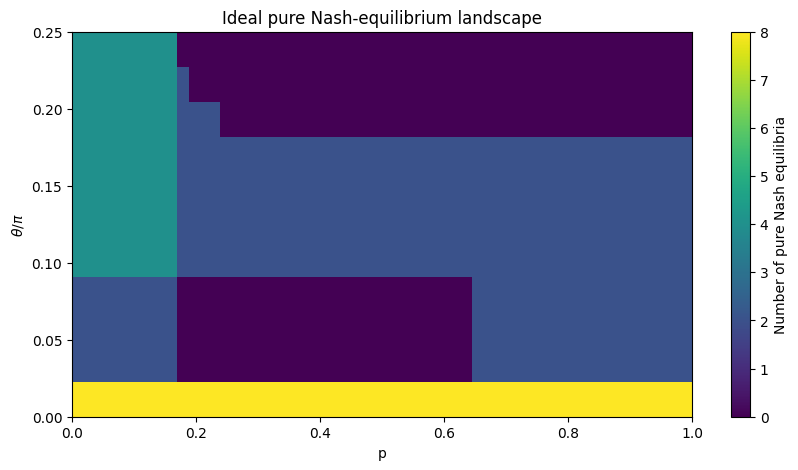

In [57]:
plt.figure(figsize=(10, 5))

plt.imshow(
    strict_map,
    aspect="auto",
    origin="lower",
    extent=[
        0,
        1,
        THETA_VALUES[0] / np.pi,
        THETA_VALUES[-1] / np.pi
    ],
    interpolation="nearest"
)

plt.colorbar(
    label="Number of pure Nash equilibria"
)

plt.xlabel("p")
plt.ylabel(r"$\theta/\pi$")

plt.title(
    "Ideal pure Nash-equilibrium landscape"
)

plt.show()

COMMENT (with the respect to the variation of theta):

- without or with very few entanglement, what happens is a very strong classical degeneracy (all the different strategies result equivalent);

- in the area of theta = 0.05pi there is exactly the scenario analyzed before;

- above the treshold of theta = 0.175pi, pure equilibria disappear again, expect for the "vertical stripe" of low p.

In [58]:
delta_map = np.zeros(
    (
        len(THETA_VALUES),
        len(P_VALUES)
    )
)

for i, theta in enumerate(THETA_VALUES):

    theta_key = round(
        float(theta / np.pi),
        3
    )

    for j, p in enumerate(P_VALUES):

        p_key = round(
            float(p),
            2
        )

        delta_map[i, j] = len(
            ideal_results[
                theta_key
            ]["delta_nash"][p_key]
        )

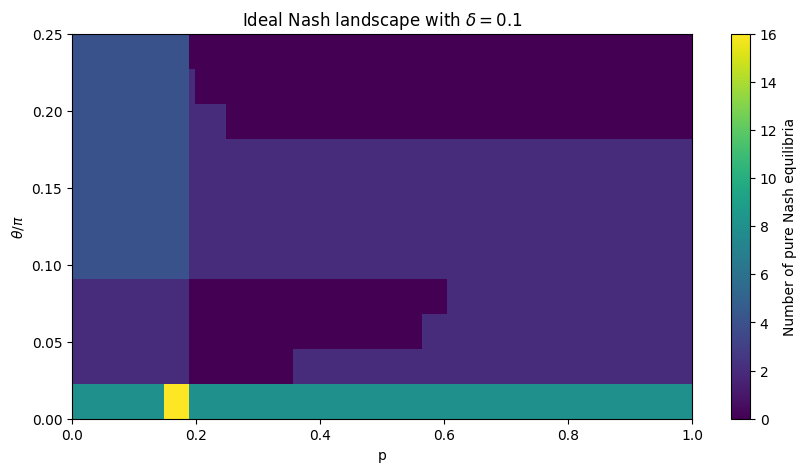

In [59]:
plt.figure(figsize=(10, 5))

plt.imshow(
    delta_map,
    aspect="auto",
    origin="lower",
    extent=[
        0,
        1,
        THETA_VALUES[0] / np.pi,
        THETA_VALUES[-1] / np.pi
    ],
    interpolation="nearest"
)

plt.colorbar(
    label="Number of pure Nash equilibria"
)

plt.xlabel("p")
plt.ylabel(r"$\theta/\pi$")

plt.title(
    r"Ideal Nash landscape with $\delta=0.1$"
)

plt.show()

COMMENT:

Now the question is no more "which is the perfect best response?" but "which responses are good enough to be almost equivalent to the optima?". So, we have definitely less purple regions, aka "no Nash equilibrium" region.

Here we can observe the same result as the paper for the transitions with theta = 0.05pi.

In general, delta-map is experimentally meaningful, since it is logical to suppose that a player will not probably change their move for "only" 0.1 gain in payoff. The introduced tollerance makes sense in reality.

-----------------------

IQM SIMULATION

In [60]:
print("Backend:", backend)
print("Number of qubits:", backend.num_qubits)

print("\nSupported operations:")
print(backend.target.operation_names)

Backend: <iqm.qiskit_iqm.iqm_provider.IQMBackend object at 0x7966f2133230>
Number of qubits: 5

Supported operations:
dict_keys(['id', 'delay', 'measure', 'r', 'if_else', 'reset', 'cz'])


In [61]:
print(backend.target)

Target
Number of qubits: 5
Instructions:
	id
		(0,)
		(1,)
		(2,)
		(3,)
		(4,)
	delay
		(0,)
		(1,)
		(2,)
		(3,)
		(4,)
	measure
		(0,)
		(1,)
		(2,)
		(3,)
		(4,)
	r
		(0,)
		(1,)
		(2,)
		(3,)
		(4,)
	if_else
	reset
		(0,)
		(1,)
		(2,)
		(3,)
		(4,)
	cz
		(0, 2)
		(1, 2)
		(2, 3)
		(2, 4)



In [62]:
def add_measurements(circuit):
    """
    Return a copy of the circuit with measurements
    on all qubits.
    """

    measured_circuit = circuit.copy()
    measured_circuit.measure_all()

    return measured_circuit

In [63]:
theta_test = 0.0

logical_IZ = create_5q_IZ_circuit(theta_test)
logical_XY = create_5q_XY_circuit(theta_test)

hardware_IZ = add_measurements(logical_IZ)
hardware_XY = add_measurements(logical_XY)

In [64]:
print(hardware_IZ.draw("text"))

        ┌─────────┐┌───┐      ┌─────────┐ ░ ┌─┐            
   q_0: ┤0        ├┤ X ├────■─┤0        ├─░─┤M├────────────
        │  Rxx(0) │└─┬─┘    │ │  Rxx(0) │ ░ └╥┘┌─┐         
   q_1: ┤1        ├──┼───■──┼─┤1        ├─░──╫─┤M├─────────
        └──┬───┬──┘  │   │  │ └─────────┘ ░  ║ └╥┘┌─┐      
   q_2: ───┤ H ├─────■───┼──┼─────────────░──╫──╫─┤M├──────
           ├───┤         │  │             ░  ║  ║ └╥┘┌─┐   
   q_3: ───┤ H ├─────────┼──■─────────────░──╫──╫──╫─┤M├───
           ├───┤         │                ░  ║  ║  ║ └╥┘┌─┐
   q_4: ───┤ H ├─────────■────────────────░──╫──╫──╫──╫─┤M├
           └───┘                          ░  ║  ║  ║  ║ └╥┘
meas: 5/═════════════════════════════════════╩══╩══╩══╩══╩═
                                             0  1  2  3  4 


In [65]:
transpiled_IZ = transpile(
    hardware_IZ,
    backend=backend
)

transpiled_XY = transpile(
    hardware_XY,
    backend=backend
)

In [66]:
print("LOGICAL CIRCUIT")
print("=" * 60)

print("Depth:", hardware_IZ.depth())
print("Operations:")
print(hardware_IZ.count_ops())


print("\nTRANSPILED CIRCUIT")
print("=" * 60)

print("Depth:", transpiled_IZ.depth())
print("Operations:")
print(transpiled_IZ.count_ops())

LOGICAL CIRCUIT
Depth: 5
Operations:
OrderedDict({'measure': 5, 'h': 3, 'rxx': 2, 'cz': 2, 'cx': 1, 'barrier': 1})

TRANSPILED CIRCUIT
Depth: 12
Operations:
OrderedDict({'r': 10, 'cz': 6, 'measure': 5, 'barrier': 1})


In [67]:
print(transpiled_IZ.draw("text"))

           ┌──────────┐                                      ┌────────────┐   »
q_3 -> 4 ──┤ R(π/2,π) ├────────────────────────────────────■─┤ R(π/2,π/2) ├─■─»
         ┌─┴──────────┴┐                                   │ └────────────┘ │ »
q_0 -> 2 ┤ R(π/2,3π/2) ├─■─────────────────────────────────┼────────────────┼─»
         ├─────────────┤ │ ┌─────────────┐   ┌───────────┐ │ ┌───────────┐  │ »
q_4 -> 0 ┤ R(π/2,3π/2) ├─■─┤ R(π/2,5π/2) ├─■─┤ R(π/2,2π) ├─■─┤ R(π/2,2π) ├──■─»
         └─────────────┘   └─────────────┘ │ └───────────┘   └───────────┘    »
q_2 -> 1 ──────────────────────────────────┼──────────────────────────────────»
         ┌─────────────┐                   │                                  »
q_1 -> 3 ┤ R(π/2,3π/2) ├───────────────────■──────────────────────────────────»
         └─────────────┘                                                      »
 meas: 5/═════════════════════════════════════════════════════════════════════»
                                        

COMMENT:

H, X, CX, RXX are NOT native in our hardware -> transpiler must decompose them in R and CZ gates.

Connectivity is a star, where the middle qubit is the third one, namely q2.

The mapping automatically chose by the transpiler is:

- logical q0 = A  → physical 2;
- logical q1 = B  → physical 3;
- logical q2 = x  → physical 4;
- logical q3 = y  → physical 1;
- logical q4 = z  → physical 0.


This is a very smart choice since A is the qubit which interacts more, btw a bit of routing is impossible to avoid here. That's why we have depth = 12.

FIRST JOB / SANITY CHECK

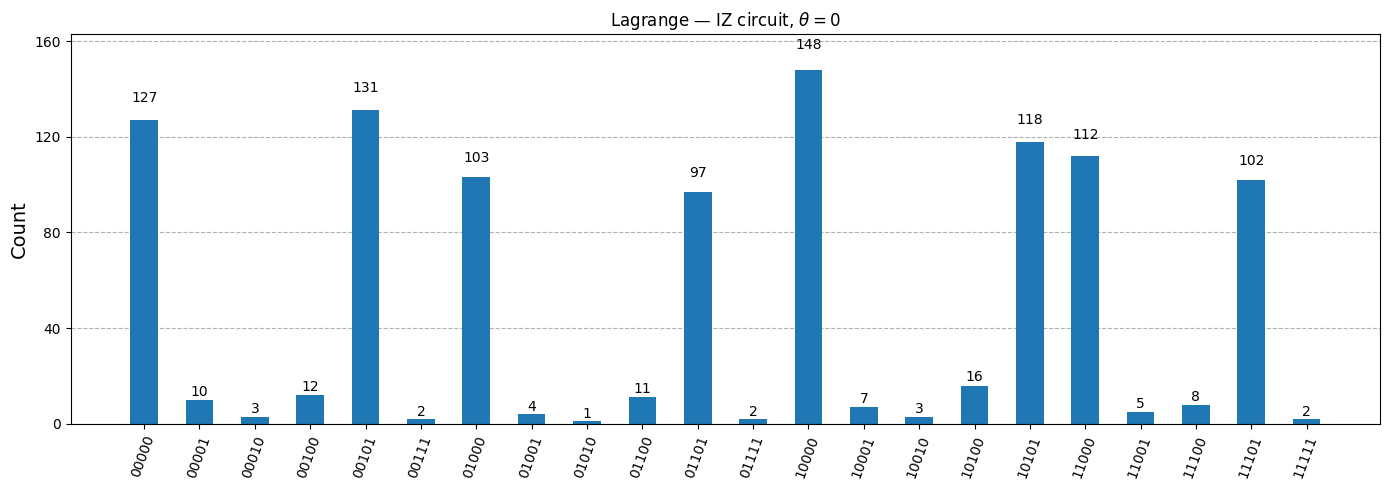

In [68]:
job = backend.run(
    [transpiled_IZ],
    shots=1024
)

result = job.result()
counts_IZ = result.get_counts()

plot_histogram(
    counts_IZ,
    title=r"Lagrange — IZ circuit, $\theta=0$",
    figsize=(14, 5)
)

In [69]:
def decode_5q_counts(counts, block):
    """
    Decode hardware counts into conditional A-B
    outcome probabilities for each strategy pair.
    """

    branch_counts = {}
    outcome_counts = {}

    # Initialize all 8 strategy branches
    for x, y, z in product([0, 1], repeat=3):

        UA = AUX_TO_A_STRATEGY[(x, y)]

        if block == "IZ":
            UB = AUX_TO_B_IZ[z]

        elif block == "XY":
            UB = AUX_TO_B_XY[z]

        else:
            raise ValueError(
                "block must be 'IZ' or 'XY'"
            )

        pair = (UA, UB)

        branch_counts[pair] = 0

        outcome_counts[pair] = {
            "00": 0,
            "01": 0,
            "10": 0,
            "11": 0
        }

    # Decode every measured 5-bit string
    for bitstring, count in counts.items():

        bitstring = bitstring.replace(" ", "")

        # Qiskit: q4 q3 q2 q1 q0
        # We want: q0 q1 q2 q3 q4
        bits = bitstring[::-1]

        A = int(bits[0])
        B = int(bits[1])

        x = int(bits[2])
        y = int(bits[3])
        z = int(bits[4])

        UA = AUX_TO_A_STRATEGY[(x, y)]

        if block == "IZ":
            UB = AUX_TO_B_IZ[z]
        else:
            UB = AUX_TO_B_XY[z]

        pair = (UA, UB)
        outcome = f"{A}{B}"

        branch_counts[pair] += count
        outcome_counts[pair][outcome] += count

    # Conditional probabilities P(AB | strategy pair)
    probabilities = {}

    for pair in outcome_counts:

        total = branch_counts[pair]

        probabilities[pair] = {
            outcome:
                outcome_counts[pair][outcome] / total
                if total > 0 else np.nan

            for outcome in [
                "00", "01", "10", "11"
            ]
        }

    return (
        branch_counts,
        outcome_counts,
        probabilities
    )

IMPORTANT !!!!

Do not forget Qiskit's little-endian convention. This is the reason for the line:

bits = bitstring[::-1]

In [70]:
(
    branch_counts_IZ,
    outcome_counts_IZ,
    hardware_probabilities_IZ
) = decode_5q_counts(
    counts_IZ,
    block="IZ"
)

In [71]:
print("AUXILIARY BRANCH COUNTS")
print("=" * 50)

for pair, count in branch_counts_IZ.items():

    print(
        f"{pair}: "
        f"{count}"
    )

AUXILIARY BRANCH COUNTS
('I', 'I'): 140
('I', 'Z'): 158
('Z', 'I'): 108
('Z', 'Z'): 117
('X', 'I'): 145
('X', 'Z'): 134
('Y', 'I'): 110
('Y', 'Z'): 112


In [72]:
print("\nHARDWARE CONDITIONAL PROBABILITIES")
print("=" * 70)

for pair, probs in hardware_probabilities_IZ.items():

    print(
        pair,
        {
            outcome: round(prob, 4)
            for outcome, prob
            in probs.items()
        }
    )


HARDWARE CONDITIONAL PROBABILITIES
('I', 'I') {'00': 0.9071, '01': 0.0214, '10': 0.0714, '11': 0.0}
('I', 'Z') {'00': 0.9367, '01': 0.019, '10': 0.0443, '11': 0.0}
('Z', 'I') {'00': 0.9537, '01': 0.0093, '10': 0.037, '11': 0.0}
('Z', 'Z') {'00': 0.9573, '01': 0.0, '10': 0.0427, '11': 0.0}
('X', 'I') {'00': 0.0828, '01': 0.0, '10': 0.9034, '11': 0.0138}
('X', 'Z') {'00': 0.1194, '01': 0.0, '10': 0.8806, '11': 0.0}
('Y', 'I') {'00': 0.1, '01': 0.0, '10': 0.8818, '11': 0.0182}
('Y', 'Z') {'00': 0.0714, '01': 0.0, '10': 0.9107, '11': 0.0179}


SECOND JOB / SANITY CHECK

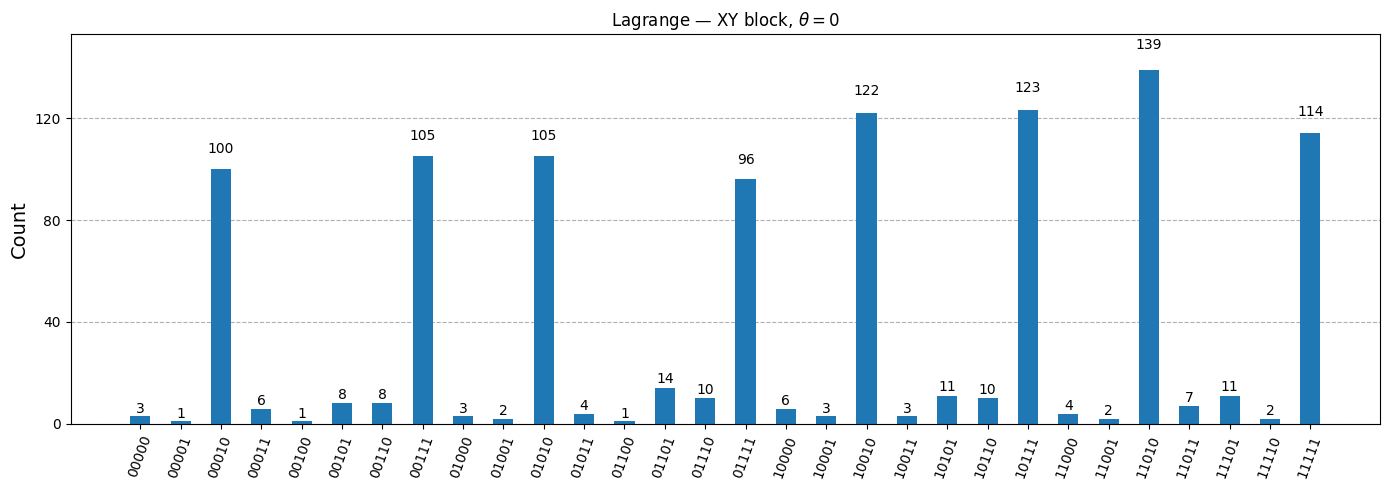

In [73]:
job_XY = backend.run(
    [transpiled_XY],
    shots=1024
);

result_XY = job_XY.result();
counts_XY = result_XY.get_counts();

plot_histogram(
    counts_XY,
    title=r"Lagrange — XY block, $\theta=0$",
    figsize=(14, 5)
)

In [74]:
(
    branch_counts_XY,
    outcome_counts_XY,
    hardware_probabilities_XY
) = decode_5q_counts(
    counts_XY,
    block="XY"
)

In [75]:
for pair, probs in hardware_probabilities_XY.items():

    dominant_outcome = max(
        probs,
        key=probs.get
    )

    print(
        f"{pair}: "
        f"{dominant_outcome} "
        f"({probs[dominant_outcome]:.3f})"
    )

('I', 'X'): 01 (0.909)
('I', 'Y'): 01 (0.910)
('Z', 'X'): 01 (0.921)
('Z', 'Y'): 01 (0.914)
('X', 'X'): 11 (0.861)
('X', 'Y'): 11 (0.854)
('Y', 'X'): 11 (0.793)
('Y', 'Y'): 11 (0.898)


  OK, THE THETA = 0 CASES ARE EQUIVALENT TO CLASSICAL OUTCOMES. NOW LET'S CHECK THETA DIFFERENT FROM ZERO...

In [76]:
theta_test = np.pi / 20

# Logical 5-qubit circuits
logical_IZ_q = create_5q_IZ_circuit(theta_test)
logical_XY_q = create_5q_XY_circuit(theta_test)

# Add measurements
hardware_IZ_q = add_measurements(logical_IZ_q)
hardware_XY_q = add_measurements(logical_XY_q)

# Transpile for Lagrange
transpiled_IZ_q = transpile(
    hardware_IZ_q,
    backend=backend
)

transpiled_XY_q = transpile(
    hardware_XY_q,
    backend=backend
)

In [77]:
print("IZ CIRCUIT")
print("Depth:", transpiled_IZ_q.depth())
print("Operations:", transpiled_IZ_q.count_ops())

print("\nXY CIRCUIT")
print("Depth:", transpiled_XY_q.depth())
print("Operations:", transpiled_XY_q.count_ops())

IZ CIRCUIT
Depth: 19
Operations: OrderedDict({'r': 17, 'cz': 10, 'measure': 5, 'barrier': 1})

XY CIRCUIT
Depth: 21
Operations: OrderedDict({'r': 19, 'cz': 10, 'measure': 5, 'barrier': 1})


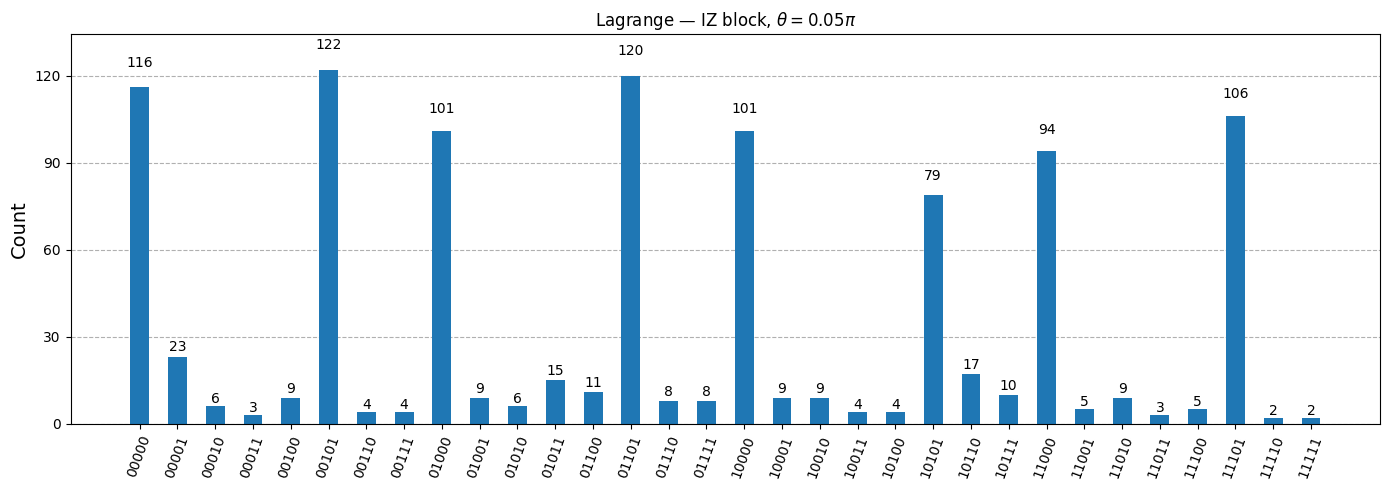

In [78]:
job_IZ_q = backend.run(
    [transpiled_IZ_q],
    shots=1024
);

result_IZ_q = job_IZ_q.result();
counts_IZ_q = result_IZ_q.get_counts();

plot_histogram(
    counts_IZ_q,
    title=r"Lagrange — IZ block, $\theta=0.05\pi$",
    figsize=(14, 5)
)

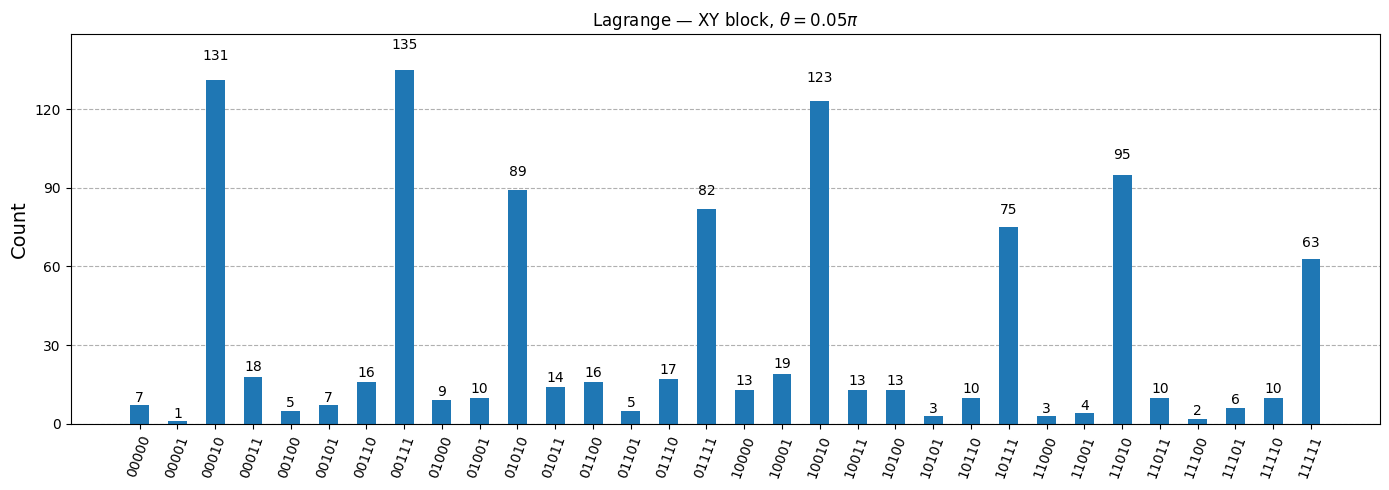

In [79]:
job_XY_q = backend.run(
    [transpiled_XY_q],
    shots=1024
);

result_XY_q = job_XY_q.result();
counts_XY_q = result_XY_q.get_counts();

plot_histogram(
    counts_XY_q,
    title=r"Lagrange — XY block, $\theta=0.05\pi$",
    figsize=(14, 5)
)

In [80]:
(
    branch_counts_IZ_q,
    outcome_counts_IZ_q,
    hardware_probabilities_IZ_q
) = decode_5q_counts(
    counts_IZ_q,
    block="IZ"
)


(
    branch_counts_XY_q,
    outcome_counts_XY_q,
    hardware_probabilities_XY_q
) = decode_5q_counts(
    counts_XY_q,
    block="XY"
)

In [81]:
hardware_probabilities_q = {}

hardware_probabilities_q.update(
    hardware_probabilities_IZ_q
)

hardware_probabilities_q.update(
    hardware_probabilities_XY_q
)

In [82]:
ideal_probabilities_q, _, _, _ = build_payoff_matrices(
    theta_test
)

In [83]:
comparison_rows = []

for UA, UB in product(
    STRATEGIES,
    repeat=2
):

    pair = (UA, UB)

    ideal = ideal_probabilities_q[pair]
    hardware = hardware_probabilities_q[pair]

    comparison_rows.append({
        "UA": UA,
        "UB": UB,

        "Ideal P00": ideal["00"],
        "HW P00": hardware["00"],

        "Ideal P01": ideal["01"],
        "HW P01": hardware["01"],

        "Ideal P10": ideal["10"],
        "HW P10": hardware["10"],

        "Ideal P11": ideal["11"],
        "HW P11": hardware["11"]
    })


comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df.round(3)

,UA,UB,Ideal P00,HW P00,Ideal P01,HW P01,Ideal P10,HW P10,Ideal P11,HW P11
0,I,I,1.000,0.784,0.000,0.041,0.000,0.155,0.000,0.020
1,I,X,0.000,0.045,1.000,0.834,0.000,0.006,0.000,0.115
2,I,Y,0.000,0.077,0.905,0.732,0.095,0.113,0.000,0.077
3,I,Z,0.905,0.821,0.000,0.073,0.000,0.073,0.095,0.033
4,X,I,0.000,0.065,0.000,0.029,1.000,0.878,0.000,0.029
5,X,X,0.000,0.031,0.000,0.098,0.000,0.043,1.000,0.828
6,X,Y,0.095,0.129,0.000,0.099,0.000,0.030,0.905,0.743
7,X,Z,0.000,0.036,0.095,0.155,0.905,0.718,0.000,0.091
8,Y,I,0.000,0.075,0.095,0.054,0.905,0.816,0.000,0.054
9,Y,X,0.095,0.133,0.000,0.142,0.000,0.042,0.905,0.683


In [84]:
print(
    "MAX PROBABILITY ERROR — "
    r"$\theta = 0.05\pi$"
)

print("=" * 60)

for UA, UB in product(
    STRATEGIES,
    repeat=2
):

    pair = (UA, UB)

    ideal = ideal_probabilities_q[pair]
    hardware = hardware_probabilities_q[pair]

    max_error = max(
        abs(
            ideal[outcome]
            -
            hardware[outcome]
        )
        for outcome in [
            "00",
            "01",
            "10",
            "11"
        ]
    )

    print(
        f"{pair}: "
        f"{max_error:.3f}"
    )

MAX PROBABILITY ERROR — $\theta = 0.05\pi$
('I', 'I'): 0.216
('I', 'X'): 0.166
('I', 'Y'): 0.172
('I', 'Z'): 0.083
('X', 'I'): 0.122
('X', 'X'): 0.172
('X', 'Y'): 0.162
('X', 'Z'): 0.186
('Y', 'I'): 0.088
('Y', 'X'): 0.221
('Y', 'Y'): 0.222
('Y', 'Z'): 0.078
('Z', 'I'): 0.134
('Z', 'X'): 0.175
('Z', 'Y'): 0.152
('Z', 'Z'): 0.153


Great result. The structure of the game is definetely preserved, but hardware leakage is not negligible... (spiegare errore)

In [85]:
# Esperiments on real hardware
print("Starting hardware campaign on IQM Lagrange...")

shots = 1024
experimental_counts = {}

for theta in THETA_VALUES:
    theta_key = round(float(theta / np.pi), 3)
    print(f"Executing for theta = {theta_key}π...")
    
    circ_iz = create_5q_IZ_circuit(theta)
    circ_xy = create_5q_XY_circuit(theta)
    
    hw_iz = add_measurements(circ_iz)
    hw_xy = add_measurements(circ_xy)
    
    transpiled_iz = transpile(hw_iz, backend=backend, optimization_level=3)
    transpiled_xy = transpile(hw_xy, backend=backend, optimization_level=3)
    
    job_iz = backend.run([transpiled_iz], shots=shots)
    job_xy = backend.run([transpiled_xy], shots=shots)
    
    experimental_counts[theta_key] = {
        "IZ_counts": job_iz.result().get_counts(),
        "XY_counts": job_xy.result().get_counts(),
        "IZ_job_id": job_iz.job_id(),
        "XY_job_id": job_xy.job_id()
    }

print("Campagna hardware completata. Raw counts salvati correttamente.")

Starting hardware campaign on IQM Lagrange...
Executing for theta = 0.0π...
Executing for theta = 0.025π...
Executing for theta = 0.05π...
Executing for theta = 0.075π...
Executing for theta = 0.1π...
Executing for theta = 0.125π...
Executing for theta = 0.15π...
Executing for theta = 0.175π...
Executing for theta = 0.2π...
Executing for theta = 0.225π...
Executing for theta = 0.25π...
Campagna hardware completata. Raw counts salvati correttamente.


In [86]:
# 12 - POST-PROCESSING HARDWARE DATA
experimental_results = {}

print("Starting Post-processing...")
for theta in THETA_VALUES:
    theta_key = round(float(theta / np.pi), 3)
    
    # Decodifica counts in probabilità
    _, _, probs_iz_exp = decode_5q_counts(experimental_counts[theta_key]["IZ_counts"], block="IZ")
    _, _, probs_xy_exp = decode_5q_counts(experimental_counts[theta_key]["XY_counts"], block="XY")
    
    hw_probs = {}
    hw_probs.update(probs_iz_exp)
    hw_probs.update(probs_xy_exp)
    
    # Inizializzazione Matrici di Payoff sperimentali
    matrix_A_exp = pd.DataFrame(index=STRATEGIES, columns=STRATEGIES, dtype=float)
    matrix_B1_exp = pd.DataFrame(index=STRATEGIES, columns=STRATEGIES, dtype=float)
    matrix_B2_exp = pd.DataFrame(index=STRATEGIES, columns=STRATEGIES, dtype=float)
    
    # Popolamento matrici con Payoff attesi
    for UA, UB in product(STRATEGIES, repeat=2):
        pair = (UA, UB)
        payoff_A_B1, payoff_B1 = calculate_payoff(hw_probs[pair], PAYOFF_B1)
        payoff_A_B2, payoff_B2 = calculate_payoff(hw_probs[pair], PAYOFF_B2)
        
        matrix_A_exp.loc[UA, UB] = payoff_A_B1
        matrix_B1_exp.loc[UA, UB] = payoff_B1
        matrix_B2_exp.loc[UA, UB] = payoff_B2
        
    # Ricerca degli equilibri di Nash (con tolleranza delta) vs p
    delta_nash_exp = {}
    
    for p in P_VALUES:
        p_key = round(float(p), 2)
        delta_nash_exp[p_key] = find_nash_equilibria_delta(
            p=p_key, 
            matrix_A=matrix_A_exp, 
            matrix_B1=matrix_B1_exp, 
            matrix_B2=matrix_B2_exp, 
            delta=0.1
        )
        
    delta_regions_exp = compact_nash_regions(delta_nash_exp)
    
    # Salvataggio nel dizionario riassuntivo
    experimental_results[theta_key] = {
        "probabilities": hw_probs,
        "matrix_A": matrix_A_exp,
        "matrix_B1": matrix_B1_exp,
        "matrix_B2": matrix_B2_exp,
        "delta_nash": delta_nash_exp,
        "delta_regions": delta_regions_exp
    }

print("Post-processing completato! Matrici ed equilibri hardware calcolati.")

Starting Post-processing...
Post-processing completato! Matrici ed equilibri hardware calcolati.


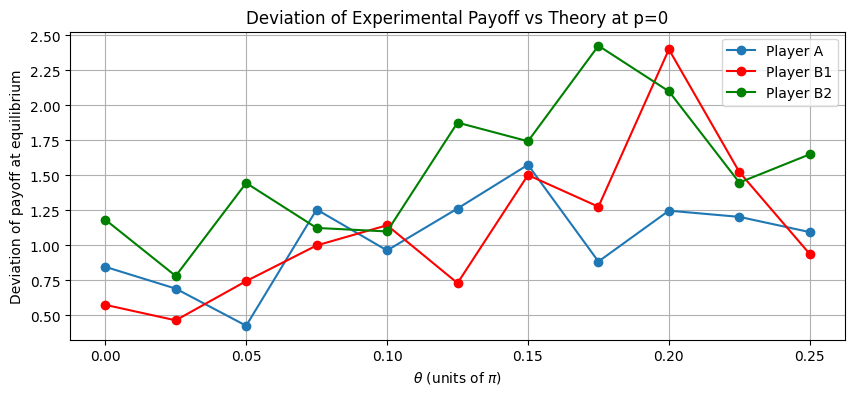

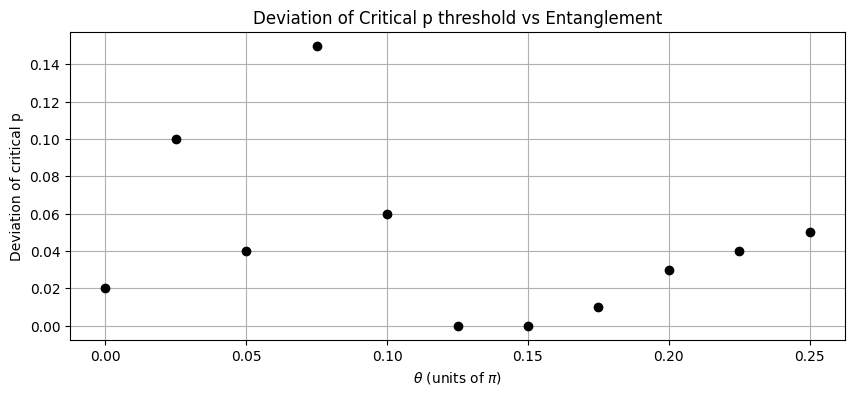

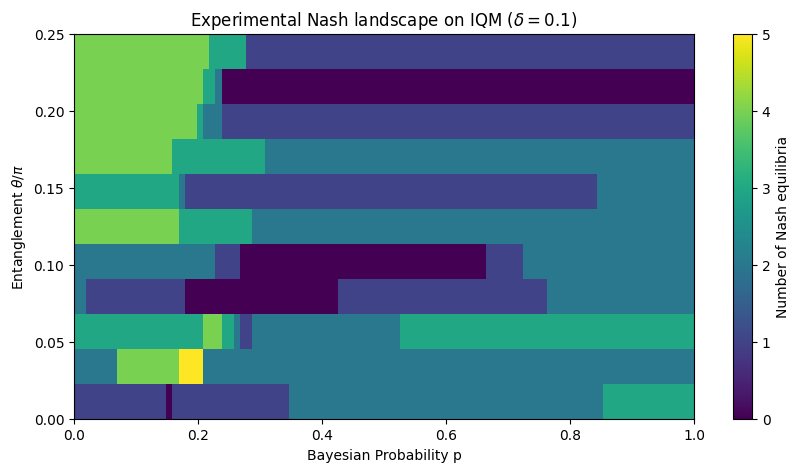

In [87]:
# 13 - CONFRONTO FINALE: DEVIATIONS AND RMSD
import matplotlib.pyplot as plt
import seaborn as sns

deviation_A = []
deviation_B1 = []
deviation_B2 = []
critical_p_deviation = []

# Analisi per ciascun valore di theta
for theta in THETA_VALUES:
    theta_key = round(float(theta / np.pi), 3)
    
    # 1. Deviazione Payoff per p=0 (Riproduzione logica Fig. 4 del paper ion-trap)
    # L'equilibrio di riferimento teorico per p=0 è {I, X, I} -> UA='I', UB1='X', UB2='I'
    # Per p=0 il Player A incontra sempre B2, quindi l'outcome A dipende da (I,I) e l'outcome B1 da (I,X) ecc.
    payoff_A_th = ideal_results[theta_key]["matrix_A"].loc["I", "I"]
    payoff_A_ex = experimental_results[theta_key]["matrix_A"].loc["I", "I"]
    
    payoff_B1_th = ideal_results[theta_key]["matrix_B1"].loc["I", "X"]
    payoff_B1_ex = experimental_results[theta_key]["matrix_B1"].loc["I", "X"]
    
    payoff_B2_th = ideal_results[theta_key]["matrix_B2"].loc["I", "I"]
    payoff_B2_ex = experimental_results[theta_key]["matrix_B2"].loc["I", "I"]
    
    deviation_A.append(abs(payoff_A_th - payoff_A_ex))
    deviation_B1.append(abs(payoff_B1_th - payoff_B1_ex))
    deviation_B2.append(abs(payoff_B2_th - payoff_B2_ex))
    
    # 2. Spostamento del critical p (Riproduzione logica Fig. 5)
    # Estraiamo il limite finale della prima regione di Nash (prima transizione di fase)
    regions_ex = experimental_results[theta_key]["delta_regions"]
    p_crit_ex = regions_ex[0][1] if len(regions_ex) > 0 else 0.16 
    
    critical_p_deviation.append(abs(0.16 - p_crit_ex))


# Plot 1: Deviation in payoff vs Entanglement
theta_axis = [round(float(t/np.pi), 3) for t in THETA_VALUES]

plt.figure(figsize=(10,4))
plt.plot(theta_axis, deviation_A, 'o-', label='Player A')
plt.plot(theta_axis, deviation_B1, 'ro-', label='Player B1')
plt.plot(theta_axis, deviation_B2, 'go-', label='Player B2')
plt.xlabel(r'$\theta$ (units of $\pi$)')
plt.ylabel('Deviation of payoff at equilibrium')
plt.title('Deviation of Experimental Payoff vs Theory at p=0')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Deviation of critical p vs Entanglement
plt.figure(figsize=(10,4))
plt.plot(theta_axis, critical_p_deviation, 'ko')
plt.xlabel(r'$\theta$ (units of $\pi$)')
plt.ylabel('Deviation of critical p')
plt.title('Deviation of Critical p threshold vs Entanglement')
plt.grid(True)
plt.show()

# Plot 3: Heatmap Landscape (delta=0.1)
delta_map_ex = np.zeros((len(THETA_VALUES), len(P_VALUES)))
for i, theta in enumerate(THETA_VALUES):
    theta_key = round(float(theta / np.pi), 3)
    for j, p in enumerate(P_VALUES):
        p_key = round(float(p), 2)
        delta_map_ex[i, j] = len(experimental_results[theta_key]["delta_nash"][p_key])

plt.figure(figsize=(10, 5))
plt.imshow(delta_map_ex, aspect="auto", origin="lower", 
           extent=[0, 1, THETA_VALUES[0]/np.pi, THETA_VALUES[-1]/np.pi], interpolation="nearest")
plt.colorbar(label="Number of Nash equilibria")
plt.xlabel("Bayesian Probability p")
plt.ylabel(r"Entanglement $\theta/\pi$")
plt.title(r"Experimental Nash landscape on IQM ($\delta=0.1$)")
plt.show()